<a href="https://colab.research.google.com/github/huzaifamulla/UIN-231A017-_-NLP-EXPERIMENTS/blob/main/NLP_EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")

Name:Mulla Huzaifa Sufyan. UIN:231A017


In [2]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

Name:Mulla Huzaifa Sufyan. UIN:231A017


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

...

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
# Combine train and test
df = pd.concat(
    [dataset["train"].to_pandas(),
     dataset["test"].to_pandas()],
    ignore_index=True
)
# Rename target column
df = df.rename(columns={"label": "labels"})

print(df.shape)
print(df.columns)
print(df["labels"].value_counts())

Name:Mulla Huzaifa Sufyan. UIN:231A017
(50000, 2)
Index(['text', 'labels'], dtype='object')
labels
0    25000
1    25000
Name: count, dtype: int64


In [7]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
#check missing values and duplicates
print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of Duplicate rows:")
print(df.duplicated().sum())

#basic text statistic
df["char_count"]=df["text"].apply(lambda x: len(x))
df["word_count"]=df["text"].apply(lambda x: len(x.split()))

df["unique_word_count"]=df["text"].apply(lambda x: len(set(x.split())))

df["avg_word_length"]=df["text"].apply(lambda x: sum(len(word) for word in x.split())/len(x.split()))
print("\nText Statistics:")
df[
    ["char_count", "word_count", "unique_word_count", "avg_word_length"]
].describe()


Name:Mulla Huzaifa Sufyan. UIN:231A017

Missing values:
text                 0
labels               0
char_count           0
word_count           0
unique_word_count    0
avg_word_length      0
dtype: int64

Number of Duplicate rows:
418

Text Statistics:


,char_count,word_count,unique_word_count,avg_word_length
count,50000.000000,50000.000000,50000.00000,50000.000000
mean,1309.431020,231.156940,152.14090,4.640676
std,989.728014,171.343997,91.76515,0.340731
min,32.000000,4.000000,4.00000,1.239865
25%,699.000000,126.000000,94.00000,4.417904
50%,970.000000,173.000000,123.00000,4.627006
75%,1590.250000,280.000000,185.00000,4.847458
max,13704.000000,2470.000000,1118.00000,12.290909


In [11]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
import re

def clean_text(text):
    #Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    #Keep alphabetic characters only
    text = re.sub(r" [^a-z\s]", " ", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Using 'text' instead of the non-existent 'review' column
df["clean_text"] = df["text"].astype(str).apply(clean_text)

print("\nOriginal Review:")
print(df["text"].iloc[0][:500])
print("\nCleaned Review:")
print(df["clean_text"].iloc[0][:500])

Name:Mulla Huzaifa Sufyan. UIN:231A017

Original Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Cleaned Review:
i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered controversial" i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything sh

Name:Mulla Huzaifa Sufyan. UIN:231A017


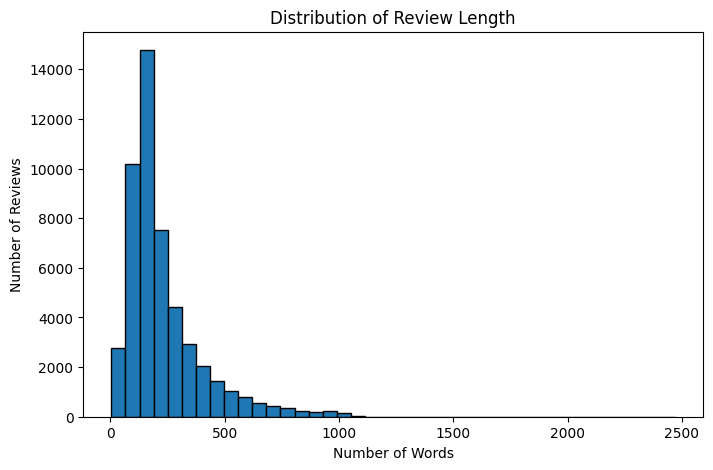

Total number of words: 11307310
Vocabulary size: 397748


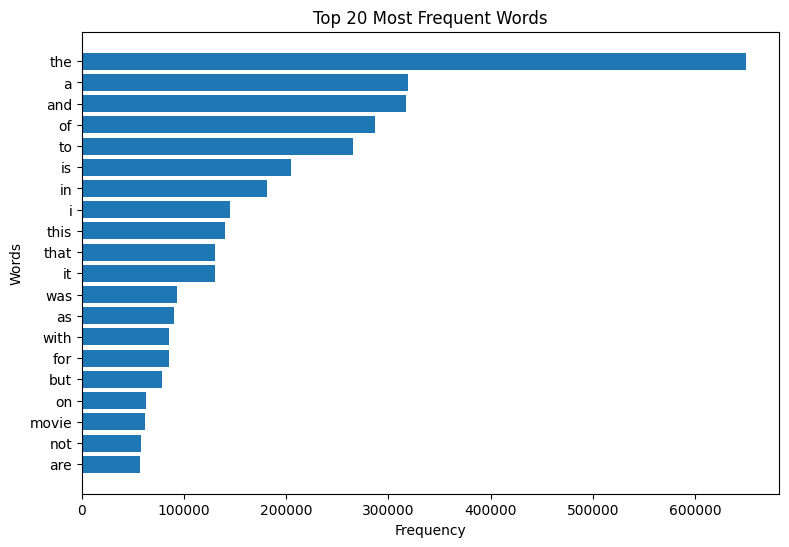

In [17]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
import matplotlib.pyplot as plt
from collections import Counter
#
#5. DOCUMENT LENGTH DISTRIBUTION
#
plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=40, edgecolor="black")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")
plt.show()
#
#6. CREATE WORD LIST
#
all_words = " ".join(df["clean_text"]).split()
print("Total number of words:", len(all_words))
print("Vocabulary size:", len(set(all_words)))
#
#7. MOST FREQUENT WORDS
#
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)
words = [word for word, count in top_words]
counts = [count for word, count in top_words]
plt.figure(figsize=(9, 6))
plt.barh (words [::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")
plt.show()

Name:Mulla Huzaifa Sufyan. UIN:231A017


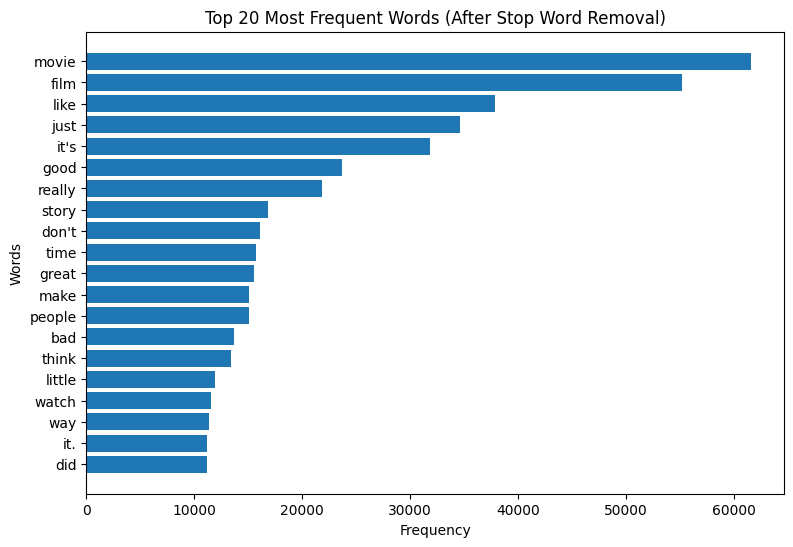

In [19]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from collections import Counter

#8. REMOVE STOP WORDS
#
vectorizer = CountVectorizer(
    stop_words="english"
)
#Fixed: Changed "clean_review" to "clean_text"
vectorizer.fit(df["clean_text"])
stop_words = vectorizer.get_stop_words()

filtered_words = [
    word for word in all_words
    if word not in stop_words
]

filtered_freq = Counter(filtered_words)
top_filtered = filtered_freq.most_common(20)

words = [word for word, count in top_filtered]
counts = [count for word, count in top_filtered]

plt.figure(figsize=(9, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (After Stop Word Removal)")
plt.show()

Name:Mulla Huzaifa Sufyan. UIN:231A017


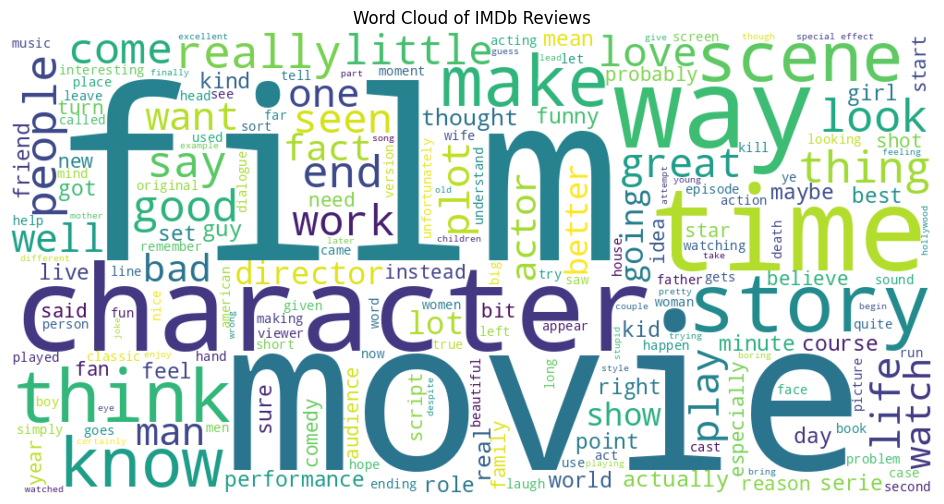

In [21]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#
#9. WORD CLOUD
#
clean_text_combined = " ".join(filtered_words)
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of IMDb Reviews")
plt.show()

In [27]:
print("Name:Mulla Huzaifa Sufyan. UIN:231A017")
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

#
#10. BIGRAM ANALYSIS
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

# Fixed: Changed "clean_review" to "clean_text"
bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text"]
)

bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_df = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
})

bigram_df = bigram_df.sort_values(
    "Frequency",
    ascending=False
)

print("\nTop Bigrams:")
print(bigram_df.head(10))

Name:Mulla Huzaifa Sufyan. UIN:231A017

Top Bigrams:
             Bigram  Frequency
15          ve seen       4167
14  special effects       2250
0          don know       2200
6        low budget       1823
5        looks like       1678
18         year old       1598
8        movie just       1540
16       waste time       1522
2        good movie       1516
13           sci fi       1393
